<a href="https://colab.research.google.com/github/Allendecodes/Pandas_part_2/blob/main/Pandas_part_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

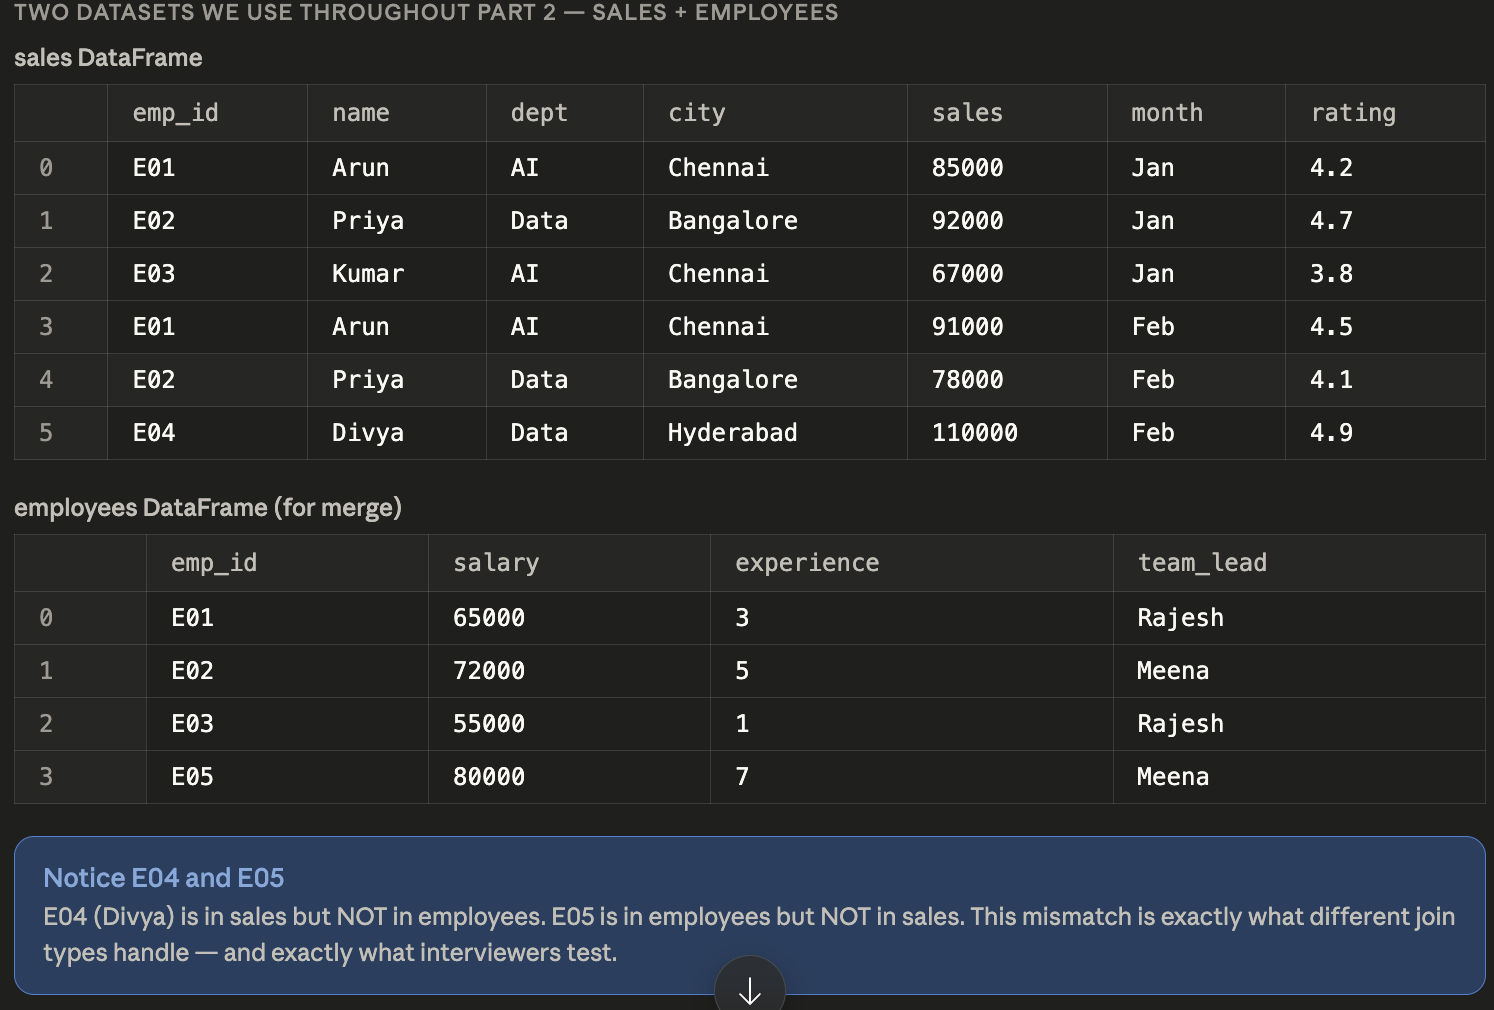

#Groupby
groupby splits the DataFrame into groups, applies a function to each group, then combines the results. Equivalent to SQL's GROUP BY. The most tested Pandas concept in analytics interviews.



In [ ]:
import pandas as pd
dfs = pd.DataFrame({
    'emp_id'  : ['E01','E02','E03','E01','E02','E04'],
    'name'    : ['Arun','Priya','Kumar','Arun','Priya','Divya'],
    'dept'    : ['AI','Data','AI','AI','Data','Data'],
    'city'    : ['Chennai','Bangalore','Chennai','Chennai','Bangalore','Hyderabad'],
    'sales'   : [85000, 92000, 67000, 91000, 78000, 110000],
    'month'   : ['Jan','Jan','Jan','Feb','Feb','Feb'],
    'rating'  : [4.2, 4.7, 3.8, 4.5, 4.1, 4.9]
})

dfe = pd.DataFrame({
    'emp_id'     : ['E01','E02','E03','E05'],
    'salary'     : [65000, 72000, 55000, 80000],
    'experience' : [3, 5, 1, 7],
    'team_lead'  : ['Rajesh','Meena','Rajesh','Meena']
})

In [ ]:
dfs.head(6)

,emp_id,name,dept,city,sales,month,rating
0,E01,Arun,AI,Chennai,85000,Jan,4.2
1,E02,Priya,Data,Bangalore,92000,Jan,4.7
2,E03,Kumar,AI,Chennai,67000,Jan,3.8
3,E01,Arun,AI,Chennai,91000,Feb,4.5
4,E02,Priya,Data,Bangalore,78000,Feb,4.1
5,E04,Divya,Data,Hyderabad,110000,Feb,4.9


In [ ]:
dfe.head(6)

,emp_id,salary,experience,team_lead
0,E01,65000,3,Rajesh
1,E02,72000,5,Meena
2,E03,55000,1,Rajesh
3,E05,80000,7,Meena


In [ ]:
dfs.groupby('dept')['sales'].sum() # Total sales per department

,sales
dept,
AI,243000
Data,280000


In [ ]:
dfs.groupby('city')['rating'].mean() # Mean rating per city

,rating
city,
Bangalore,4.400000
Chennai,4.166667
Hyderabad,4.900000


In [ ]:
dfs.groupby('dept')['name'].count()  # Count rows per department

,name
dept,
AI,3
Data,3


In [ ]:
dfs.groupby('dept')['sales'].agg(['sum', 'mean', 'max', 'min']) # Multiple aggregations on same column

,sum,mean,max,min
dept,,,,
AI,243000,81000.000000,91000,67000
Data,280000,93333.333333,110000,78000


aggregation

In [ ]:
dfs.groupby('dept').agg({
    'sales' : ['min','max','sum'],
    'rating' : 'mean',
    'name'   : 'count'
})

sales                    rating  name
        min     max     sum      mean count
dept                                       
AI    67000   91000  243000  4.166667     3
Data  78000  110000  280000  4.566667     3

In [ ]:
# Named aggregation — cleaner column names (modern pandas),giving manual names
dfs.groupby('dept').agg(
    total_sales  = ('sales', 'sum'),
    avg_rating   = ('rating', 'mean'),
    num_entries  = ('name', 'count')
).reset_index()

,dept,total_sales,avg_rating,num_entries
0,AI,243000,4.166667,3
1,Data,280000,4.566667,3


In [ ]:
# Sales per department per month
dfs.groupby(['dept', 'month'])['sales'].sum()

dept  month
AI    Feb       91000
      Jan      152000
Data  Feb      188000
      Jan       92000
Name: sales, dtype: int64

In [ ]:
dfs.groupby(['dept','month'], as_index=False)['sales'].sum() # as_index=False → keeps group cols as regular columns

,dept,month,sales
0,AI,Feb,91000
1,AI,Jan,152000
2,Data,Feb,188000
3,Data,Jan,92000
